In [1]:
import pandas as pd
import numpy as np
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import f1_score, make_scorer, accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from sklearn.base import clone
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report
from imblearn.pipeline import Pipeline
from sklearn.feature_selection import SequentialFeatureSelector as SFS
from sklearn.feature_selection import RFECV
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Import the functions from the prep_functions notebook
#%run "./02_prep_functions.ipynb"

# Download the notebook from the URL
!wget https://raw.githubusercontent.com/gascalero/DM_II_project/Features_prep_6/notebooks/02_prep_functions.ipynb

# Now run the downloaded notebook using the local path
get_ipython().run_line_magic('run', '-i "02_prep_functions.ipynb"')

# Check if the main functions and variables are imported correctly
print("Function imported correctly:")
print(f"- preprocess_train_df: {preprocess_train_df.__name__}")
print(f"- preprocess_test_df: {preprocess_test_df.__name__}")
print(f"- split_sets: {split_sets.__name__}")

"wget" no se reconoce como un comando interno o externo,
programa o archivo por lotes ejecutable.


Function imported correctly:
- preprocess_train_df: preprocess_train_df
- preprocess_test_df: preprocess_test_df
- split_sets: split_sets


# 1. INITIAL READING OF THE DATASET AND PREPROCESSING PIPELINES EXECUTION

In [3]:
# Reading CSV files with pandas

cancer_df = pd.read_csv('https://raw.githubusercontent.com/gascalero/DM_II_project/4a73ca4928f2b95f960cd9b9f44c4700244ed553/data/raw/patient_train_data.csv',
                        encoding='UTF-8',
                        index_col=0,
                        sep=',',
                        on_bad_lines='skip',
                        quoting=3)
cancer_df.head(1)

# Splitting the dataset into training and validation sets
X_train, X_val, y_train, y_val = split_sets(cancer_df)

# Running the preprocessing pipeline for the training set
X_train_processed, y_train_processed, mode_train, stats_pre, encoders = preprocess_train_df(X_train, y_train, columns_to_delete, values_to_imput_cat, binary_cols, ordinal_mappings, numeric_cols, categorical_cols)

# Running the preprocessing pipeline for the validation set

X_val_processed = preprocess_test_df(X_val, X_train_processed.columns, values_to_imput_cat, columns_to_delete, mode_train, stats_pre, binary_cols, numeric_cols, categorical_cols, encoders)

# y_val_processed = y_val.copy() for following the same convention as X_val_processed
y_val_processed = y_val.copy()

Dimension of X_train: (60028, 30)
Dimension of X_test: (15007, 30)
Dimension of y_train: (60028,)
Dimension of y_test: (15007,)


# 2. FEATURE SELECTION

## 2.1 RIDGE

In [ ]:
from sklearn.linear_model import RidgeCV
ridge = RidgeCV(alphas=np.logspace(-6, 6, num=5)).fit(X_train_processed, y_train_processed)
importance = np.abs(ridge.coef_)
feature_names = np.array(X_train_processed.columns)
coefficients = ridge.coef_
feature_importance_pairs = np.array(list(zip(importance, feature_names, coefficients)), dtype=object)
sorted_features = feature_importance_pairs[np.argsort(-feature_importance_pairs[:, 0])]
for importance, feature, coef in sorted_features:
    print(f"{feature}: {coef:.4f} (Importance: {importance:.4f})")

Early_Detection_Treatment: 0.0003 (Importance: 0.0003)
Cancer_Severity: -0.0002 (Importance: 0.0002)
Treatment Type_Radiotherapy: -0.0001 (Importance: 0.0001)
Cardiometabolic_Risk: 0.0001 (Importance: 0.0001)
Advanced_Age: 0.0001 (Importance: 0.0001)
Tumor Size (mm): -0.0001 (Importance: 0.0001)
Early Detection: 0.0001 (Importance: 0.0001)
Cancer Stage: -0.0001 (Importance: 0.0001)
Treatment_Effectiveness: 0.0001 (Importance: 0.0001)
Gender: -0.0001 (Importance: 0.0001)
Country_Italy: -0.0001 (Importance: 0.0001)
Alcohol Consumption: 0.0001 (Importance: 0.0001)
Treatment Type_Combination: -0.0001 (Importance: 0.0001)
Heart Disease History: 0.0000 (Importance: 0.0000)
Insurance Status_Uninsured: 0.0000 (Importance: 0.0000)
Mortality Rate per 100K: -0.0000 (Importance: 0.0000)
Hypertension_Yes: -0.0000 (Importance: 0.0000)
Diabetes: 0.0000 (Importance: 0.0000)
Country_Germany: -0.0000 (Importance: 0.0000)
Country_UK: 0.0000 (Importance: 0.0000)
Inflammatory Bowel Disease: 0.0000 (Importa

In [ ]:
selected_features_ridge = [
    'Early_Detection_Treatment',
    'Cancer_Severity',
    'Treatment Type_Radiotherapy',
    'Cardiometabolic_Risk',
    'Advanced_Age',
    'Tumor Size (mm)',
    'Early Detection',
    'Cancer Stage',
    'Treatment_Effectiveness',
    'Gender',
    'Country_Italy',
    'Alcohol Consumption'
]

## 2.2. SFS

In [ ]:
lr = LogisticRegression(max_iter=500)
sbs_fwd = SFS(lr, direction='forward', scoring='accuracy', cv=None, n_features_to_select=15)
sbs_fwd.fit(X_train_processed, y_train_processed)
selected_features_SBS_fwd = feature_names[sbs_fwd.get_support()]
print(selected_features_SBS_fwd)

['Alcohol Consumption' 'Cancer Stage' 'Diabetes' 'Diet Risk'
 'Early Detection' 'Family History' 'Gender' 'Genetic Mutation'
 'Healthcare Access' 'Healthcare Costs' 'Heart Disease History'
 'Incidence Rate per 100K' 'Inflammatory Bowel Disease'
 'Mortality Rate per 100K' 'Obesity BMI']


In [ ]:
selected_features_SBS_fwd = [
    'Alcohol Consumption', 'Cancer Stage', 'Diabetes', 'Diet Risk',
    'Early Detection', 'Family History', 'Gender', 'Genetic Mutation',
    'Healthcare Access', 'Healthcare Costs', 'Heart Disease History',
    'Incidence Rate per 100K', 'Inflammatory Bowel Disease',
    'Mortality Rate per 100K', 'Obesity BMI'
]

In [6]:
feature_names = np.array(X_train_processed.columns)
lr = LogisticRegression(max_iter=500)
sbs_back = SFS(lr, direction='backward', scoring='f1_macro', cv=None, n_features_to_select=15)
sbs_back.fit(X_train_processed,y_train_processed)
selected_features_SBS_back = feature_names[sbs_back.get_support()]

print(selected_features_SBS_back)

['Country_Nigeria' 'Country_Pakistan' 'Country_South Africa'
 'Country_South Korea' 'Country_UK' 'Country_USA'
 'Insurance Costs_Extended' 'Insurance Costs_No insurance'
 'Treatment Type_Combination' 'Treatment Type_Radiotherapy'
 'Treatment Type_Surgery' 'Hypertension_Yes' 'Insurance Status_Uninsured'
 'Non Smoker_Yes' 'Urban or Rural_Urban']


In [4]:
selected_features_SBS_back = [
    'Country_Nigeria', 'Country_Pakistan', 'Country_South Africa',
    'Country_South Korea', 'Country_UK', 'Country_USA',
    'Insurance Costs_Extended', 'Insurance Costs_No insurance',
    'Treatment Type_Combination', 'Treatment Type_Radiotherapy',
    'Treatment Type_Surgery', 'Hypertension_Yes', 'Insurance Status_Uninsured',
    'Non Smoker_Yes', 'Urban or Rural_Urban'
]

## 2.2. RFECV

In [4]:
estimator = LogisticRegression(max_iter=500)

rfecv_selector = RFECV(
    estimator=estimator,
    step=1,
    cv=5,
    scoring='f1_macro',
    min_features_to_select=15,
    n_jobs=-1
)

rfecv_selector.fit(X_train_processed, y_train_processed)

selected_mask = rfecv_selector.support_
selected_features_rfecv = X_train_processed.columns[selected_mask].tolist()
n_selected = len(selected_features_rfecv)

print(selected_features_rfecv)

['Early Detection', 'Screening History', 'Early_Detection_Treatment', 'Country_Brazil', 'Country_China', 'Country_France', 'Country_Germany', 'Country_India', 'Country_Italy', 'Country_New Zealand', 'Country_Nigeria', 'Country_Pakistan', 'Country_South Korea', 'Country_USA', 'Treatment Type_Radiotherapy']


In [14]:
selected_features_rfecv = ['Early Detection', 'Screening History', 'Early_Detection_Treatment',
                           'Country_Brazil', 'Country_China', 'Country_France', 'Country_Germany',
                           'Country_India', 'Country_Italy', 'Country_New Zealand', 'Country_Nigeria',
                           'Country_Pakistan', 'Country_South Korea', 'Country_USA', 'Treatment Type_Radiotherapy']

# 2. MODEL EVALUATION AND SELECTION (CROSS-VALIDATION)

In [12]:
# Define initial models with default or basic parameters
models = {
    'LogisticRegression': LogisticRegression(class_weight='balanced', max_iter=10000, random_state=42),
    'RandomForest': RandomForestClassifier(class_weight='balanced', max_depth=5, random_state=42),
    'KNeighbors': KNeighborsClassifier(weights='distance'),
    'DecisionTree': DecisionTreeClassifier(class_weight='balanced', max_depth=5, random_state=42)
}

This function is used for evaluating models using Cross-Validation. It returns the average measures after running the trained model on each fold's validation set and training set. This helps provide an idea of possible overfitting.

In [10]:
def evaluate_models_with_cv(X, y, models_dict, cv, scoring='f1'):
    cv_splitter = StratifiedKFold(n_splits=cv, shuffle=True, random_state=42)
    f1_macro_scorer = make_scorer(f1_score)

    results = []

    for name, model in models_dict.items():
        print(f"Evaluating {name}...")
        cv_scores = cross_val_score(
            model, X, y,
            cv=cv_splitter,
            scoring=f1_macro_scorer,
            n_jobs=-1
        )

        # Calculate training scores for each fold
        train_scores = []
        for train_idx, val_idx in cv_splitter.split(X, y):
            X_train_fold, X_val_fold = X.iloc[train_idx], X.iloc[val_idx]
            y_train_fold, y_val_fold = y.iloc[train_idx], y.iloc[val_idx]

            # Train the model on the training fold
            # Use clone to avoid fitting the original model
            model_clone = clone(model)
            model_clone.fit(X_train_fold, y_train_fold)

            # Evaluate on the training fold
            # Use the same model to predict on the training fold
            y_train_pred = model_clone.predict(X_train_fold)
            train_f1 = f1_score(y_train_fold, y_train_pred)
            train_scores.append(train_f1)

        # Calculate mean and std of training scores
        train_scores = np.array(train_scores)

        results.append({
            'Model': name,
            'Mean score (Val)': cv_scores.mean(),
            'Std score (Val)': cv_scores.std(),
            'Min score (Val)': cv_scores.min(),
            'Max score (Val)': cv_scores.max(),
            'Mean score (Train)': train_scores.mean(),
            'Std score (Train)': train_scores.std(),
            'Overfit Gap': train_scores.mean() - cv_scores.mean(),
            'Val Scores': cv_scores,
            'Train Scores': train_scores
        })

    results_df = pd.DataFrame(results)
    results_df = results_df.sort_values('Mean score (Val)', ascending=False)

    return results_df

After the functions for cross-validation are designed, we execute them.

In [ ]:
cv = 5 # Number of folds for cross-validation
cv_results = evaluate_models_with_cv(X_train_processed, y_train_processed, models, cv)

# Show results
cv_results[['Model', 'Mean score (Train)', 'Std score (Train)', 'Mean score (Val)', 'Std score (Val)' ,'Overfit Gap']]

Evaluating LogisticRegression...
Evaluating RandomForest...
Evaluating KNeighbors...
Evaluating DecisionTree...


,Model,Mean score (Train),Std score (Train),Mean score (Val),Std score (Val),Overfit Gap
2,KNeighbors,1.000000,0.000000,0.641704,0.003326,0.358296
3,DecisionTree,0.618846,0.132383,0.603530,0.138190,0.015317
1,RandomForest,0.635671,0.005435,0.580603,0.006045,0.055068
0,LogisticRegression,0.569519,0.003837,0.561379,0.007572,0.008141


In [ ]:
# SBS Forward Selection

cv = 5 # Number of folds for cross-validation
cv_results = evaluate_models_with_cv(X_train_processed[selected_features_SBS_fwd], y_train_processed, models, cv)

# Show results
cv_results[['Model', 'Mean score (Train)', 'Std score (Train)', 'Mean score (Val)', 'Std score (Val)' ,'Overfit Gap']]

Evaluating LogisticRegression...
Evaluating RandomForest...
Evaluating KNeighbors...
Evaluating DecisionTree...


,Model,Mean score (Train),Std score (Train),Mean score (Val),Std score (Val),Overfit Gap
2,KNeighbors,1.000000,0.000000,0.634263,0.002017,0.365737
1,RandomForest,0.588870,0.013323,0.545150,0.014060,0.043720
0,LogisticRegression,0.542491,0.009310,0.535673,0.008688,0.006818
3,DecisionTree,0.317993,0.239365,0.306884,0.242585,0.011109


In [13]:
# SBS Backward Selection

cv = 5 # Number of folds for cross-validation
cv_results = evaluate_models_with_cv(X_train_processed[selected_features_SBS_back], y_train_processed, models, cv)

# Show results
cv_results[['Model', 'Mean score (Train)', 'Std score (Train)', 'Mean score (Val)', 'Std score (Val)' ,'Overfit Gap']]

Evaluating LogisticRegression...
Evaluating RandomForest...
Evaluating KNeighbors...
Evaluating DecisionTree...


,Model,Mean score (Train),Std score (Train),Mean score (Val),Std score (Val),Overfit Gap
3,DecisionTree,0.642945,0.024939,0.637863,0.027946,0.005082
2,KNeighbors,0.644892,0.007078,0.628180,0.009316,0.016712
1,RandomForest,0.599972,0.016299,0.585685,0.016444,0.014287
0,LogisticRegression,0.572076,0.013655,0.569162,0.013220,0.002913


In [15]:
#RFECV Selection

cv = 5 # Number of folds for cross-validation
cv_results = evaluate_models_with_cv(X_train_processed[selected_features_rfecv], y_train_processed, models, cv)

# Show results
cv_results[['Model', 'Mean score (Train)', 'Std score (Train)', 'Mean score (Val)', 'Std score (Val)' ,'Overfit Gap']]

Evaluating LogisticRegression...
Evaluating RandomForest...
Evaluating KNeighbors...
Evaluating DecisionTree...


,Model,Mean score (Train),Std score (Train),Mean score (Val),Std score (Val),Overfit Gap
3,DecisionTree,0.689265,0.009869,0.685246,0.012146,0.004019
2,KNeighbors,0.615669,0.029555,0.610094,0.030489,0.005574
0,LogisticRegression,0.570812,0.015051,0.568805,0.018698,0.002007
1,RandomForest,0.566596,0.043147,0.554135,0.040408,0.012461


In [5]:
X_train_selected = X_train_processed[selected_features_SBS_back]
X_val_selected = X_val_processed[selected_features_SBS_back]

# 3. HYPERPARAMETERS OPTIMIZATION

After the candidate models are selected, we perform a GridSearch for tuning hyperparameters to maximize performance results.

## LOGISTIC REGRESSION

In [6]:
param_grid = {
    'C': [0.01, 0.1, 1, 10, 20, 50, 100],
    'penalty': ['l1','l2'],
    'solver': ['liblinear', 'lbfgs', 'saga'],
    'class_weight': [{0: 1.5, 1: 1},'balanced'],
    'max_iter': [1000000]
}

# Create the classifier
LR_class = LogisticRegression(random_state=42)

# Define the scoring function
scorer = make_scorer(f1_score, average='macro')

# Configure GridSearchCV
grid_search = GridSearchCV(
    estimator=LR_class,
    param_grid=param_grid,
    scoring=scorer,
    cv=10,
    n_jobs=-1,
    verbose=0,
    return_train_score=True
)

# Fit the model with the training data
grid_search.fit(X_train_selected, y_train_processed)

# Show best parameters and scores
print("Best parameters:")
print(grid_search.best_params_)
print(f"Best F1 score: {grid_search.best_score_:.4f}")

Best parameters:
{'C': 1, 'class_weight': {0: 1.5, 1: 1}, 'max_iter': 1000000, 'penalty': 'l1', 'solver': 'saga'}
Best F1 score: 0.5034


In [11]:
# Create model with the best parameters

best_log_reg = LogisticRegression(C= 1, class_weight= {0: 1.5, 1: 1}, max_iter = 1000000, penalty= 'l1', solver = 'saga', random_state=42)
# Train the model with the best parameters on the entire training set
best_log_reg.fit(X_train_selected, y_train_processed)
# Evaluate the model on the validation set
y_pred_best_LR = best_log_reg.predict(X_val_selected)
print("\nClassification report with best parameters (validation set):")
print(classification_report(y_val_processed, y_pred_best_LR))
# Evaluate the model on the training set
y_pred_best_train_LR = best_log_reg.predict(X_train_selected)
print("\nClassification report with best parameters (training set):")
print(classification_report(y_train_processed, y_pred_best_train_LR))


Classification report with best parameters (validation set):
              precision    recall  f1-score   support

           0       0.40      0.44      0.42      5993
           1       0.60      0.56      0.58      9014

    accuracy                           0.51     15007
   macro avg       0.50      0.50      0.50     15007
weighted avg       0.52      0.51      0.52     15007


Classification report with best parameters (training set):
              precision    recall  f1-score   support

           0       0.41      0.45      0.43     23665
           1       0.61      0.56      0.58     35531

    accuracy                           0.52     59196
   macro avg       0.51      0.51      0.51     59196
weighted avg       0.53      0.52      0.52     59196



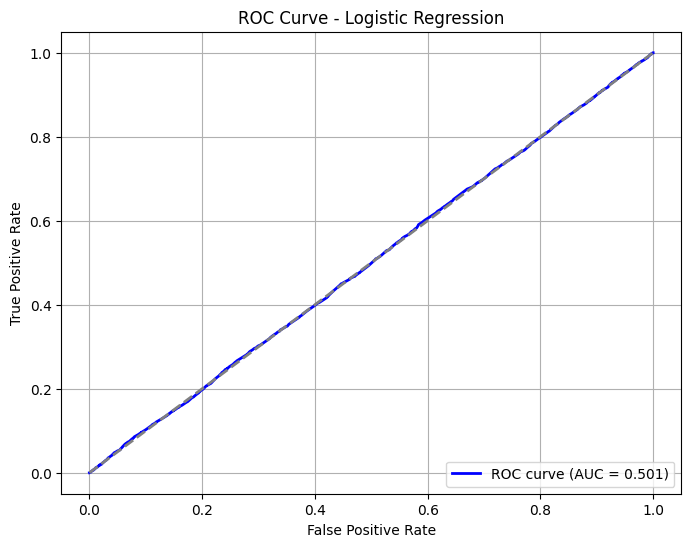

In [12]:
y_val_proba = best_log_reg.predict_proba(X_val_selected)[:, 1]

fpr, tpr, thresholds = roc_curve(y_val_processed, y_val_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

## RANDOM FOREST

In [16]:
param_grid_rf = {
    'classifier__n_estimators': [100, 200, 300],
    'classifier__max_depth': [None, 10, 20],
    'classifier__min_samples_split': [2, 5],
    'classifier__min_samples_leaf': [1, 2],
    'classifier__class_weight': [{0: 1.5, 1: 1}, 'balanced']
}

pipeline_rf = Pipeline([
    ('classifier', RandomForestClassifier(random_state=42))
])

# Define the scoring function
scorer = make_scorer(f1_score, average='macro')

# Configure GridSearchCV
# Use the pipeline and the parameter grid for Random Forest
grid_search_rf = GridSearchCV(
    estimator=pipeline_rf,
    param_grid=param_grid_rf,
    scoring=scorer,
    cv=10,
    n_jobs=-1,
    verbose=0,
    return_train_score=True
)

# Fit the model with the training data
grid_search_rf.fit(X_train_selected, y_train_processed)

# Show best parameters and scores
print("Best parameters:")
print(grid_search_rf.best_params_)
print(f"Best F1 score: {grid_search_rf.best_score_:.4f}")

Best parameters:
{'classifier__class_weight': 'balanced', 'classifier__max_depth': 10, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 100}
Best F1 score: 0.5023


In [17]:
# Create model with the best parameters

best_rf = RandomForestClassifier(class_weight= 'balanced', max_depth= 10, min_samples_leaf= 1, min_samples_split= 5, n_estimators= 100, random_state=42)

# Train the model with the best parameters on the entire training set
best_rf.fit(X_train_selected, y_train_processed)

# Evaluate the model on the validation set
y_pred_best_RF = best_rf.predict(X_val_selected)
print("\nClassification report with best parameters:")
print(classification_report(y_val_processed, y_pred_best_RF))

# Evaluate the model on the training set
y_pred_best_train_RF = best_log_reg.predict(X_train_selected)
print("\nClassification report with best parameters (training set):")
print(classification_report(y_train_processed, y_pred_best_train_RF))


Classification report with best parameters:
              precision    recall  f1-score   support

           0       0.40      0.49      0.44      5993
           1       0.61      0.52      0.56      9014

    accuracy                           0.51     15007
   macro avg       0.51      0.51      0.50     15007
weighted avg       0.53      0.51      0.51     15007


Classification report with best parameters (training set):
              precision    recall  f1-score   support

           0       0.41      0.45      0.43     23665
           1       0.61      0.56      0.58     35531

    accuracy                           0.52     59196
   macro avg       0.51      0.51      0.51     59196
weighted avg       0.53      0.52      0.52     59196



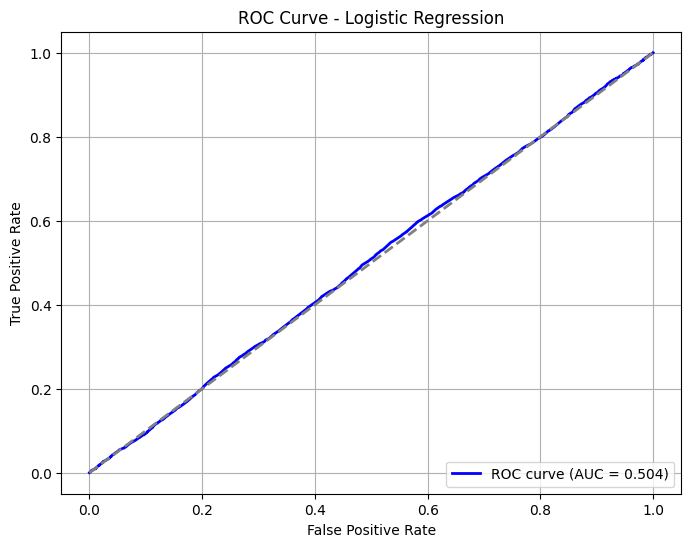

In [18]:
y_val_proba = best_rf.predict_proba(X_val_selected)[:, 1]

fpr, tpr, thresholds = roc_curve(y_val_processed, y_val_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

## ADABOOST

In [ ]:
base_estimator = DecisionTreeClassifier(
    max_depth=2,
    class_weight={0: 1.5, 1: 1}
)

param_grid_ada = {
    'n_estimators': [100, 200, 300, 400],
    'learning_rate': [0.001, 0.01, 0.1, 1],
    'estimator__max_depth': [1, 2, 3],
    'estimator__class_weight': [{0: 1.5, 1: 1}, 'balanced']
}

scorer = make_scorer(f1_score, average='macro')
grid_search_ada = GridSearchCV(
    estimator=AdaBoostClassifier(
        estimator=base_estimator,
        random_state=42
    ),
    param_grid=param_grid_ada,
    scoring=scorer,
    cv=5,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

grid_search_ada.fit(X_train_selected, y_train_processed)

print("Best parameters:")
print(grid_search_ada.best_params_)
print(f"Best F1 score: {grid_search_ada.best_score_:.4f}")

best_ada = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(
        max_depth=grid_search_ada.best_params_['estimator__max_depth'],
        class_weight=grid_search_ada.best_params_['estimator__class_weight']
    ),
    n_estimators=grid_search_ada.best_params_['n_estimators'],
    learning_rate=grid_search_ada.best_params_['learning_rate'],
    random_state=42
)
best_ada.fit(X_train_selected, y_train_processed)

Fitting 5 folds for each of 96 candidates, totalling 480 fits


In [30]:
best_ada_par = AdaBoostClassifier(estimator = base_estimator, class_weight = {0: 1.5, 1: 1}, estimator__max_depth = 2, learning_rate = 0.1, n_estimators = 100)

y_pred_best_ada = best_ada_par.predict(X_val_selected)
print("\nClassification report with best parameters (validation set):")
print(classification_report(y_val_processed, y_pred_best_ada))

y_pred_best_train_ada = best_ada.predict(X_train_selected)
print("\nClassification report with best parameters (training set):")
print(classification_report(y_train_processed, y_pred_best_train_ada))



Classification report with best parameters (validation set):
              precision    recall  f1-score   support

           0       0.40      0.30      0.34      5976
           1       0.60      0.71      0.65      9031

    accuracy                           0.54     15007
   macro avg       0.50      0.50      0.50     15007
weighted avg       0.52      0.54      0.53     15007


Classification report with best parameters (training set):
              precision    recall  f1-score   support

           0       0.41      0.31      0.35     23675
           1       0.60      0.71      0.65     35505

    accuracy                           0.55     59180
   macro avg       0.51      0.51      0.50     59180
weighted avg       0.53      0.55      0.53     59180



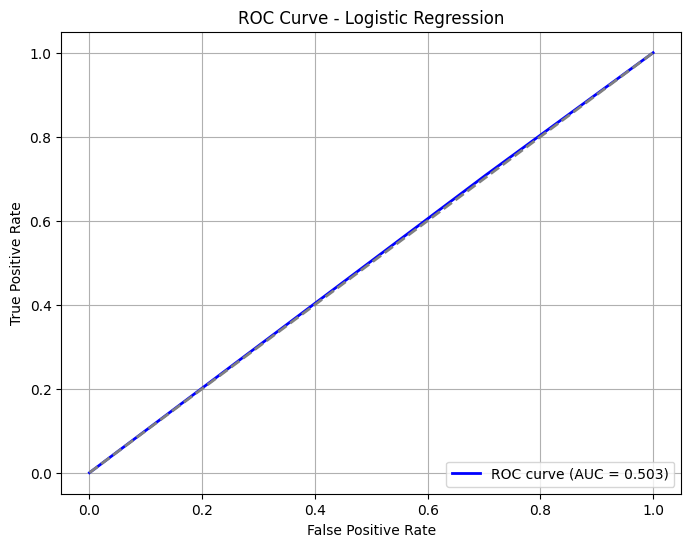

In [31]:
y_val_proba = best_ada.predict_proba(X_val_processed[selected_features_SBS_back])[:, 1]

fpr, tpr, thresholds = roc_curve(y_val_processed, y_val_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# 5. ENSAMBLE METHODS

## 5.2. STACKING CLASSIFIER

In [ ]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

base_dt = DecisionTreeClassifier(
    max_depth=3,
    class_weight={0: 1.5, 1: 1}
)

estimators = [
    ('lr', LogisticRegression(C=0.1, class_weight='balanced', max_iter=100000,
                             penalty='l1', solver='saga', random_state=42)),
    ('rf', RandomForestClassifier(class_weight={0: 1.5, 1: 1}, max_depth=10,
                                 min_samples_leaf=1, min_samples_split=2,
                                 n_estimators=300, random_state=42)),
    ('ada', AdaBoostClassifier(estimator=base_dt, n_estimators=300,
                              learning_rate=0.01,
                              random_state=42))
]

stack_model.fit(X_train_processed[selected_features_SBS_back], y_train_processed)
y_pred_stack = stack_model.predict(X_val_processed[selected_features_SBS_back])
print("\nClassification report for Stacking Classifier:")
print(classification_report(y_val_processed, y_pred_stack))

y_pred_train_stack = stack_model.predict(X_train_processed[selected_features_SBS_back])
print("\nClassification report for Stacking Classifier (training set):")
print(classification_report(y_train_processed, y_pred_train_stack))


Classification report for Stacking Classifier:
              precision    recall  f1-score   support

           0       0.41      0.53      0.46      5976
           1       0.61      0.49      0.54      9031

    accuracy                           0.50     15007
   macro avg       0.51      0.51      0.50     15007
weighted avg       0.53      0.50      0.51     15007


Classification report for Stacking Classifier (training set):
              precision    recall  f1-score   support

           0       0.44      0.57      0.50     23675
           1       0.64      0.51      0.57     35505

    accuracy                           0.54     59180
   macro avg       0.54      0.54      0.53     59180
weighted avg       0.56      0.54      0.54     59180



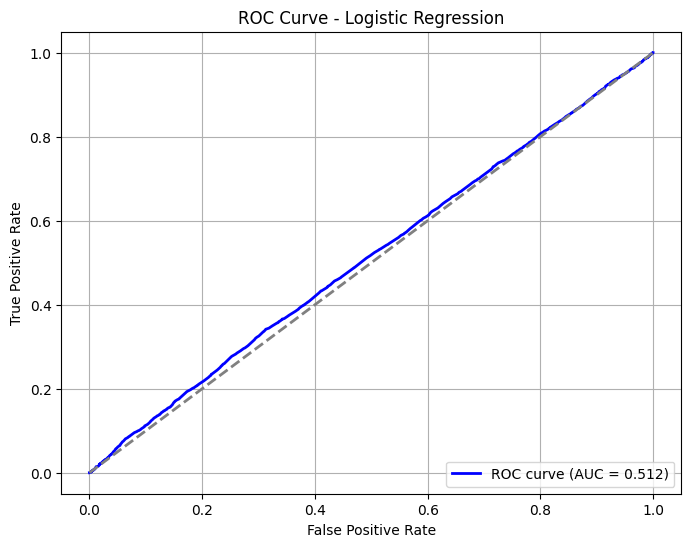

In [ ]:
y_val_proba = stack_model.predict_proba(X_val_processed[selected_features_SBS_back])[:, 1]

fpr, tpr, thresholds = roc_curve(y_val_processed, y_val_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

## 5.3. VOTING CLASSIFIER

In [ ]:
from sklearn.ensemble import VotingClassifier
from sklearn.tree import DecisionTreeClassifier

base_dt = DecisionTreeClassifier(
    max_depth=3,
    class_weight={0: 1.5, 1: 1}
)

estimators = [
    ('lr', LogisticRegression(C=0.1, class_weight='balanced', max_iter=100000,
                             penalty='l1', solver='saga', random_state=42)),
    ('rf', RandomForestClassifier(class_weight={0: 1.5, 1: 1}, max_depth=10,
                                 min_samples_leaf=1, min_samples_split=2,
                                 n_estimators=300, random_state=42)),
    ('ada', AdaBoostClassifier(estimator=base_dt, n_estimators=200,
                              learning_rate=0.01,
                              random_state=42))
]


voting_clf = VotingClassifier(
    estimators=estimators,
    voting='soft',
    weights=[3, 2, 3],
    n_jobs=-1
)

voting_clf.fit(X_train_processed[selected_features_SBS_back], y_train_processed)

y_pred_voting = voting_clf.predict(X_val_processed[selected_features_SBS_back])
print("\nClassification report for Voting Classifier (validation set):")
print(classification_report(y_val_processed, y_pred_voting))

y_pred_train_voting = voting_clf.predict(X_train_processed[selected_features_SBS_back])
print("\nClassification report for Voting Classifier (training set):")
print(classification_report(y_train_processed, y_pred_train_voting))


Classification report for Voting Classifier (validation set):
              precision    recall  f1-score   support

           0       0.41      0.41      0.41      5976
           1       0.61      0.60      0.61      9031

    accuracy                           0.53     15007
   macro avg       0.51      0.51      0.51     15007
weighted avg       0.53      0.53      0.53     15007


Classification report for Voting Classifier (training set):
              precision    recall  f1-score   support

           0       0.45      0.46      0.45     23675
           1       0.63      0.62      0.63     35505

    accuracy                           0.56     59180
   macro avg       0.54      0.54      0.54     59180
weighted avg       0.56      0.56      0.56     59180



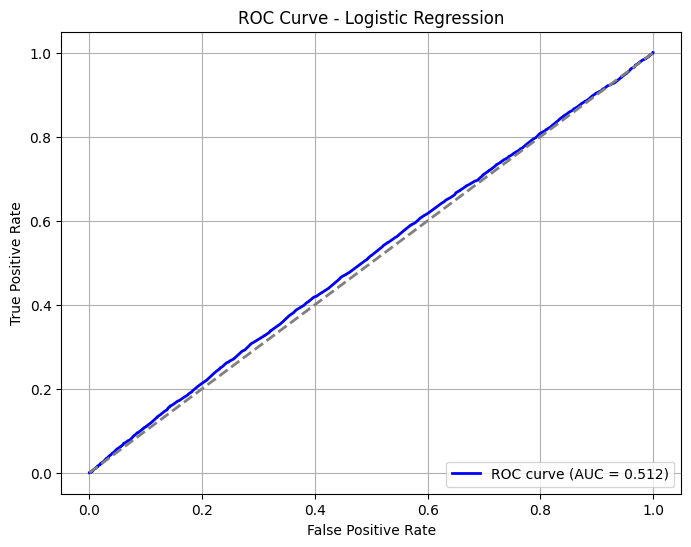

In [ ]:
y_val_proba = voting_clf.predict_proba(X_val_processed[selected_features_SBS_back])[:, 1]

fpr, tpr, thresholds = roc_curve(y_val_processed, y_val_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# 6. KAGGLE SUBMISSION CREATION

After selecting the best model with its optimal hyperparameters, it is now time to create the final CSV for submission in the Kaggle competition.

In [ ]:
# Importing the test dataset provided in the DM II project materials

test_cancer_df = pd.read_csv('https://raw.githubusercontent.com/gascalero/DM_II_project/refs/heads/master/data/raw/patient_test_data.csv',
                         encoding='UTF-8',
                         index_col=0,
                         sep=',',
                         on_bad_lines='skip',
                         quoting=3)

test_cancer_df.head(1)

# Executing the preprocessing pipeline for the final test set

X_test_processed = preprocess_test_df(test_cancer_df, X_train_processed.columns, values_to_imput_cat, columns_to_delete, mode_train, stats_pre, binary_cols, numeric_cols, categorical_cols, encoders)

Dimension of test set before preprocessing: (75000, 34)
Dimension of test set after preprocessing: (75000, 48)


## LOGISTIC REGRESSION (CANDIDATE)

In [ ]:
# Running the selected model into the test set
logistic_model = LogisticRegression(C= 0.1, class_weight= 'balanced', max_iter= 100000, penalty= 'l1', solver= 'saga')
logistic_model.fit(X_train_processed[selected_features_SBS_back], y_train_processed)
y_pred_logistic = logistic_model.predict(X_test_processed[selected_features_SBS_back])

In [ ]:
# Creating the DataFrame for Kaggle submission
df_kaggle_lr = pd.DataFrame(y_pred_logistic, index=test_cancer_df.index)
df_kaggle_lr.replace({0: 'No', 1: 'Yes'}, inplace = True)
df_kaggle_lr.columns = ['Survival Prediction']
df_kaggle_lr.value_counts()

Survival Prediction
Yes                    45902
No                     29098
Name: count, dtype: int64

In [ ]:
import os

# Exporting the DataFrame to a CSV file for submission
# Modify the file name as needed with the corresponding version number
output_dir = './data/Kaggle submissions'
os.makedirs(output_dir, exist_ok=True)  # Create the directory if it doesn't exist
df_kaggle_lr.to_csv(f'{output_dir}/DT_Group05_Version22.csv')

## RANDOM FOREST (CANDIDATE)

In [ ]:
best_rf.fit(X_train_processed[selected_features_SBS_back], y_train_processed)
y_pred_RF = best_rf.predict(X_test_processed[selected_features_SBS_back])

In [ ]:
# Creating the DataFrame for Kaggle submission
df_kaggle_rf = pd.DataFrame(y_pred_RF, index=test_cancer_df.index)
df_kaggle_rf.replace({0: 'No', 1: 'Yes'}, inplace = True)
df_kaggle_rf.columns = ['Survival Prediction']
df_kaggle_rf.value_counts()

Survival Prediction
Yes                    41460
No                     33540
Name: count, dtype: int64

In [ ]:
import os

# Exporting the DataFrame to a CSV file for submission
# Modify the file name as needed with the corresponding version number
output_dir = './data/Kaggle submissions'
os.makedirs(output_dir, exist_ok=True)  # Create the directory if it doesn't exist
df_kaggle_rf.to_csv(f'{output_dir}/DT_Group05_Version21.csv')

## ADABOOST (CANDIDATE)

In [ ]:
best_ada.fit(X_train_processed[selected_features_SBS_back], y_train_processed)
y_pred_AB = best_ada.predict(X_test_processed[selected_features_SBS_back])

In [ ]:
# Creating the DataFrame for Kaggle submission
df_kaggle_ab = pd.DataFrame(y_pred_AB, index=test_cancer_df.index)
df_kaggle_ab.replace({0: 'No', 1: 'Yes'}, inplace = True)
df_kaggle_ab.columns = ['Survival Prediction']
df_kaggle_ab.value_counts()

Survival Prediction
Yes                    40402
No                     34598
Name: count, dtype: int64

In [ ]:
import os

# Exporting the DataFrame to a CSV file for submission
# Modify the file name as needed with the corresponding version number
output_dir = './data/Kaggle submissions'
os.makedirs(output_dir, exist_ok=True)  # Create the directory if it doesn't exist
df_kaggle_ab.to_csv(f'{output_dir}/DT_Group05_Version37.csv')

## VOTING CLASSIFIER (CANDIDATE)

In [ ]:
y_pred_voting = voting_clf.predict(X_test_processed[selected_features_SBS_back])
# Creating the DataFrame for Kaggle submission
df_kaggle_voting = pd.DataFrame(y_pred_voting, index=test_cancer_df.index)
df_kaggle_voting.replace({0: 'No', 1: 'Yes'}, inplace = True)
df_kaggle_voting.columns = ['Survival Prediction']
df_kaggle_voting.value_counts()

Survival Prediction
Yes                    44582
No                     30418
Name: count, dtype: int64

In [ ]:
import os
# Exporting the DataFrame to a CSV file for submission
# Modify the file name as needed with the corresponding version number
output_dir = './data/Kaggle submissions'
os.makedirs(output_dir, exist_ok=True)  # Create the directory if it doesn't exist
df_kaggle_voting.to_csv(f'{output_dir}/DT_Group05_Version40.csv')

## STACKING (CANDIDATE)

In [ ]:
y_pred_stack = stack_model.predict(X_test_processed[selected_features_SBS_back])
# Creating the DataFrame for Kaggle submission
df_kaggle_stack = pd.DataFrame(y_pred_stack, index=test_cancer_df.index)
df_kaggle_stack.replace({0: 'No', 1: 'Yes'}, inplace = True)
df_kaggle_stack.columns = ['Survival Prediction']
df_kaggle_stack.value_counts()

Survival Prediction
No                     38196
Yes                    36804
Name: count, dtype: int64

In [ ]:
import os
# Exporting the DataFrame to a CSV file for submission
# Modify the file name as needed with the corresponding version number
output_dir = './data/Kaggle submissions'
os.makedirs(output_dir, exist_ok=True)  # Create the directory if it doesn't exist
df_kaggle_stack.to_csv(f'{output_dir}/DT_Group05_Version26.csv')

## MLP (CANDIDATE)

In [ ]:
y_pred_mlp = best_mlp.predict(X_test_processed[selected_features_SBS_back])
df_kaggle_stack = pd.DataFrame(y_pred_mlp, index=test_cancer_df.index)
df_kaggle_stack.replace({0: 'No', 1: 'Yes'}, inplace = True)
df_kaggle_stack.columns = ['Survival Prediction']
df_kaggle_stack.value_counts()

,count
Survival Prediction,
No,37573
Yes,37427
